In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, balanced_accuracy_score


# Análise Exploratória de Dados

## Análise Descritiva

In [2]:
# Dataframe com a base de dados
df = pd.read_parquet('sample_data.parquet')

In [3]:
# Shape do dataframe
# 100000 linhas e 14 colunas
df.shape

(100000, 14)

In [4]:
# Tipos de dados contidos na base
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   document_number           100000 non-null  object        
 1   yearmonth                 100000 non-null  datetime64[ns]
 2   registry_date             98700 non-null   datetime64[ns]
 3   clearance_place_dispatch  100000 non-null  object        
 4   clearance_place_entry     99960 non-null   object        
 5   consignee_code            100000 non-null  object        
 6   consignee_company_size    100000 non-null  object        
 7   consignee_name            100000 non-null  object        
 8   clearance_place           100000 non-null  object        
 9   transport_mode_pt         99960 non-null   object        
 10  ncm_code                  99941 non-null   object        
 11  shipper_name              99990 non-null   object        
 12  cou

,country_origin_code
count,99250.000000
mean,243.376101
std,167.283507
min,23.000000
25%,124.000000
50%,169.000000
75%,368.000000
max,756.000000


In [5]:
# Quantidade de valores null em cada coluna
df.isnull().sum().sort_values(ascending=False)

registry_date               1300
country_origin_code          750
ncm_code                      59
clearance_place_entry         40
transport_mode_pt             40
shipper_name                  10
document_number                0
yearmonth                      0
clearance_place_dispatch       0
consignee_code                 0
consignee_company_size         0
consignee_name                 0
clearance_place                0
channel                        0
dtype: int64

In [6]:
# Registros sem data de registro foram removidos, pois inviabilizam divisão temporal adequada e representam menos de 2% da base.
df = df.dropna(subset=['registry_date'])

In [7]:
df['country_missing'] = df['country_origin_code'].isna().astype(int)
df['country_origin_code'] = df['country_origin_code'].fillna('UNKNOWN')
df['country_origin_code'] = df['country_origin_code'].astype(str)
df['country_origin_code'] = df['country_origin_code'].fillna('UNKNOWN')
df['ncm_code'] = df['ncm_code'].fillna('UNKNOWN')
df['transport_mode_pt'] = df['transport_mode_pt'].fillna('UNKNOWN')
df['clearance_place_entry'] = df['clearance_place_entry'].fillna('UNKNOWN')


## Análise da variável target


In [8]:
# Aqui é observado que há um desbalanceamento entre as classes, com predominância do canal verde
channel_dist = df['channel'].value_counts()
channel_pct = df['channel'].value_counts(normalize=True)

display(channel_dist)
display(channel_pct)

VERDE       95758
VERMELHO     2044
AMARELO       852
CINZA          46
Name: channel, dtype: int64

VERDE       0.970193
VERMELHO    0.020709
AMARELO     0.008632
CINZA       0.000466
Name: channel, dtype: float64

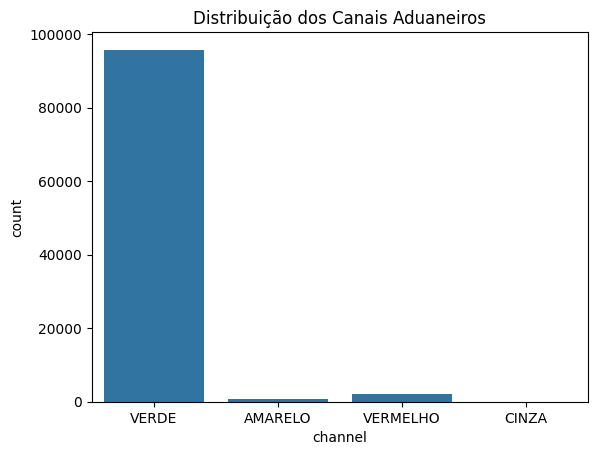

In [9]:
sns.countplot(data=df, x='channel')
plt.title("Distribuição dos Canais Aduaneiros")
plt.show()

# Visualizações:

# Features Categóricas

In [10]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

document_number 98700
clearance_place_dispatch 12
clearance_place_entry 13
consignee_code 3898
consignee_company_size 3
consignee_name 1654
clearance_place 10
transport_mode_pt 8
ncm_code 29
shipper_name 1920
country_origin_code 33
channel 4


In [11]:
df['registry_date'] = pd.to_datetime(df['registry_date'])
df['year'] = df['registry_date'].dt.year
df['month'] = df['registry_date'].dt.month
df['weekday'] = df['registry_date'].dt.dayofweek

In [12]:
df.groupby(df['registry_date'].dt.year)['ncm_code'].nunique()


registry_date
2023    29
2024    29
2025    29
Name: ncm_code, dtype: int64

<AxesSubplot:xlabel='registry_date'>

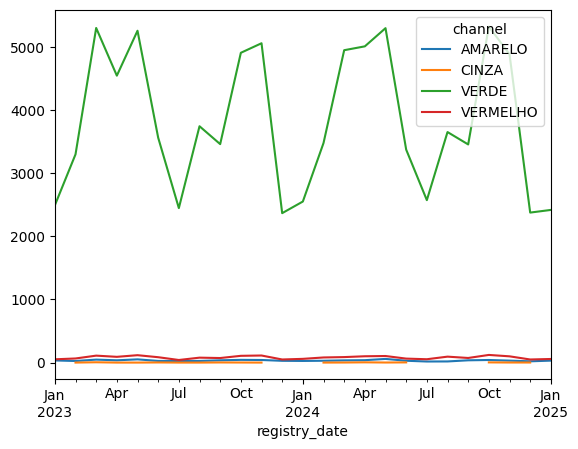

In [13]:
df.groupby([df['registry_date'].dt.to_period('M'), 'channel']).size().unstack().plot()

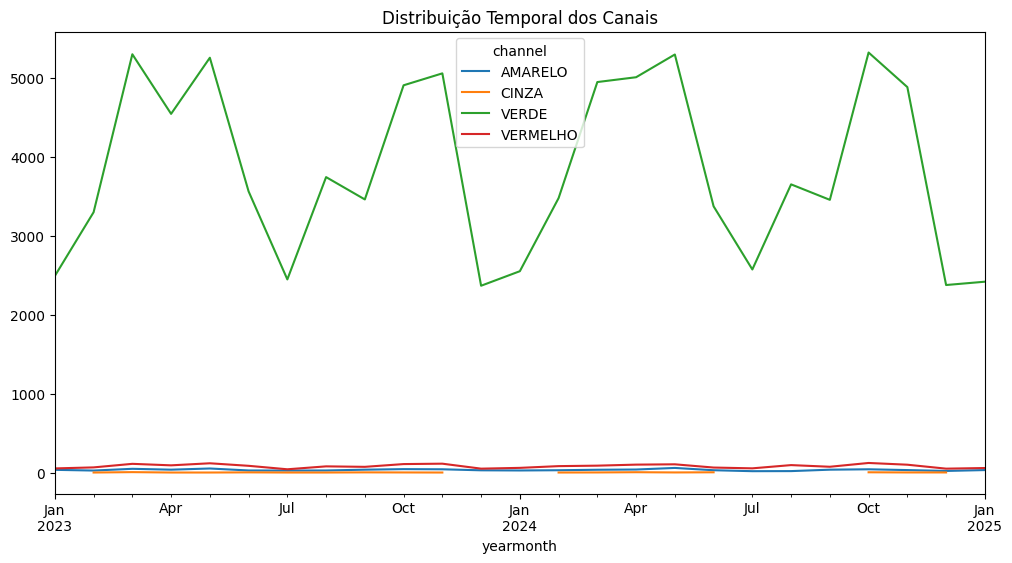

In [14]:
monthly = df.groupby(['yearmonth', 'channel']).size().unstack()
monthly.plot(figsize=(12,6))
plt.title("Distribuição Temporal dos Canais")
plt.show()

# 2. Análise Temporal

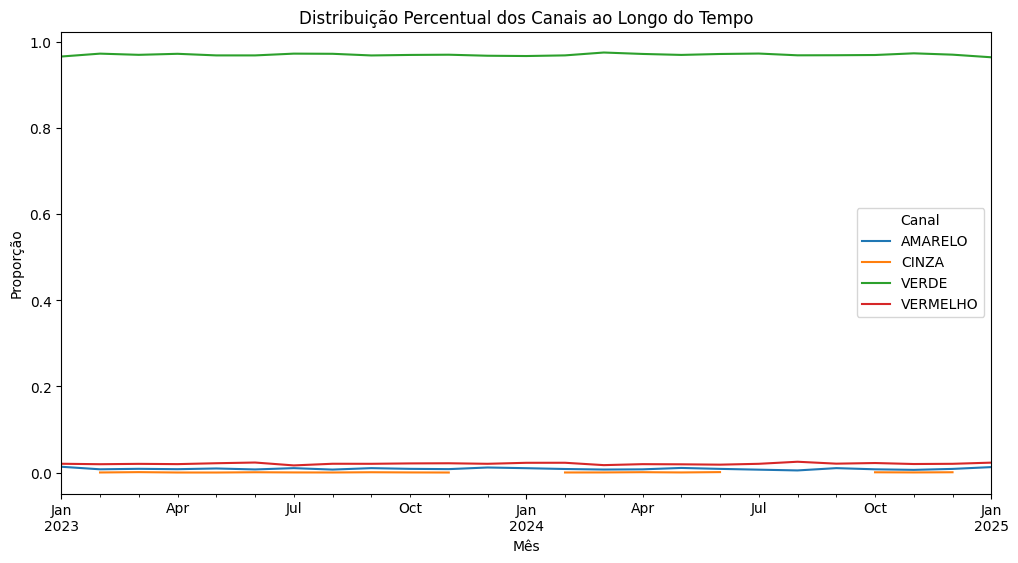

In [15]:
monthly_dist = (
    df.groupby([df['registry_date'].dt.to_period('M'), 'channel'])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack()
)

monthly_dist.plot(figsize=(12,6))
plt.title("Distribuição Percentual dos Canais ao Longo do Tempo")
plt.ylabel("Proporção")
plt.xlabel("Mês")
plt.legend(title="Canal")
plt.show()

In [16]:
monthly_risk = (
    df.groupby(df['registry_date'].dt.to_period('M'))['is_risk']
      .mean()
)

monthly_risk.plot(figsize=(12,5))
plt.title("Proporção de Operações com Fiscalização ao Longo do Tempo")
plt.ylabel("Taxa de Risco")
plt.show()

KeyError: 'Column not found: is_risk'

# 3. Visualizações de Risco


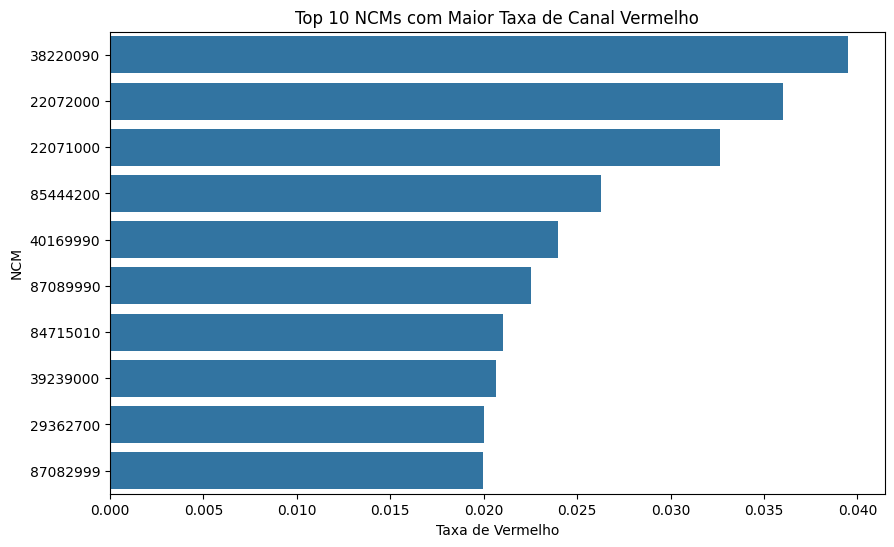

In [19]:
ncm_stats = df.groupby('ncm_code')['channel'].agg(
    total='count',
    red_rate=lambda x: (x == 'VERMELHO').mean()
)

top_ncm = ncm_stats.sort_values('red_rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_ncm['red_rate'], y=top_ncm.index)
plt.title("Top 10 NCMs com Maior Taxa de Canal Vermelho")
plt.xlabel("Taxa de Vermelho")
plt.ylabel("NCM")
plt.show()


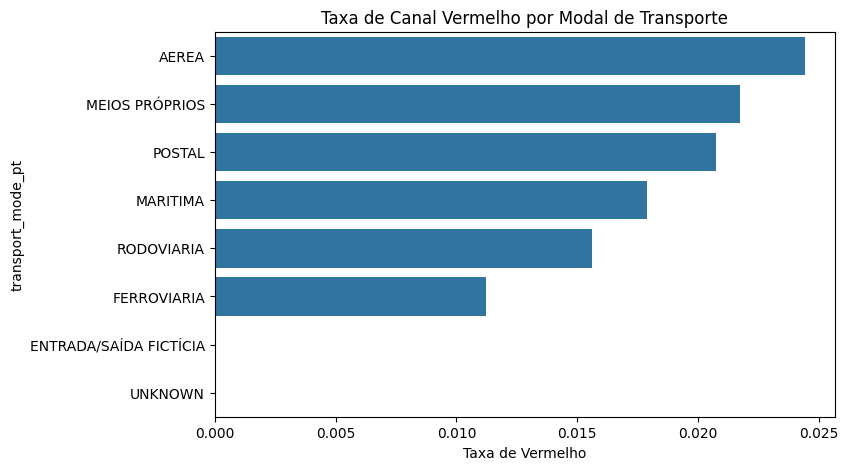

In [20]:
transport_red = (
    df.groupby('transport_mode_pt')['channel']
      .apply(lambda x: (x == 'VERMELHO').mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=transport_red.values, y=transport_red.index)
plt.title("Taxa de Canal Vermelho por Modal de Transporte")
plt.xlabel("Taxa de Vermelho")
plt.show()

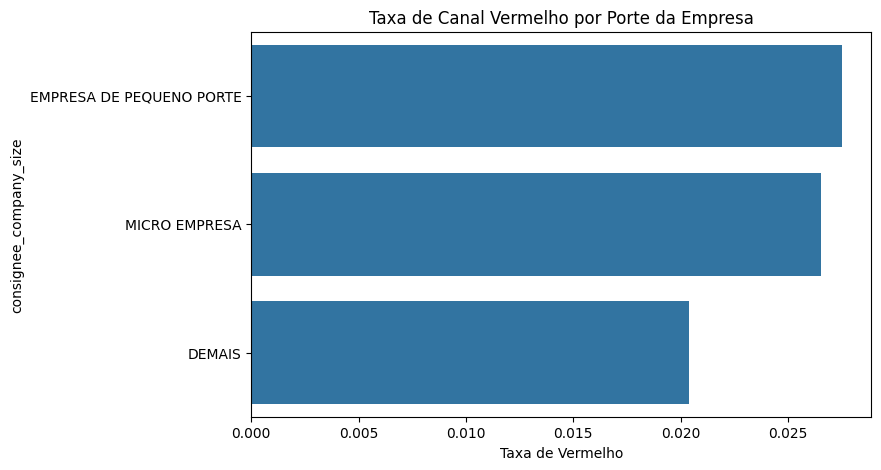

In [21]:
company_red = (
    df.groupby('consignee_company_size')['channel']
      .apply(lambda x: (x == 'VERMELHO').mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=company_red.values, y=company_red.index)
plt.title("Taxa de Canal Vermelho por Porte da Empresa")
plt.xlabel("Taxa de Vermelho")
plt.show()


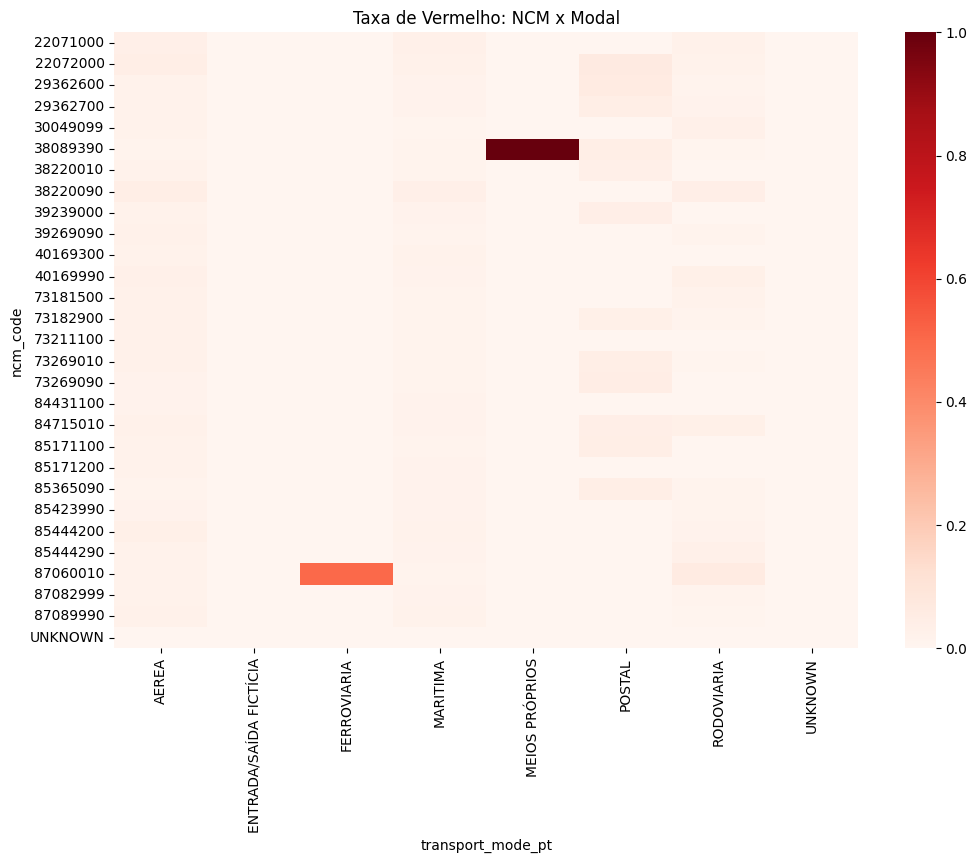

In [22]:
pivot = pd.crosstab(
    df['ncm_code'],
    df['transport_mode_pt'],
    values=(df['channel'] == 'VERMELHO'),
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot.fillna(0), cmap='Reds')
plt.title("Taxa de Vermelho: NCM x Modal")
plt.show()

In [23]:

country_red = (
    df.groupby('country_origin_code')['channel']
    .apply(lambda x: (x == 'VERMELHO').mean())
    .sort_values(ascending=False)
    .head(20)
)
country_red

country_origin_code
368.0      0.035507
UNKNOWN    0.031165
364.0      0.030679
356.0      0.030557
249.0      0.024975
756.0      0.024572
97.0       0.024439
221.0      0.022420
124.0      0.021689
169.0      0.021646
372.0      0.021015
399.0      0.020922
218.0      0.020582
137.0      0.020395
380.0      0.020238
392.0      0.019919
132.0      0.019491
51.0       0.019294
105.0      0.019194
386.0      0.019108
Name: channel, dtype: float64

In [24]:
transport_risk = (
    df.groupby('transport_mode_pt')['channel']
    .value_counts(normalize=True)
    .unstack()
)

In [25]:
transport_risk['VERMELHO'].sort_values(ascending=False)

transport_mode_pt
AEREA                     0.024423
MEIOS PRÓPRIOS            0.021739
POSTAL                    0.020725
MARITIMA                  0.017877
RODOVIARIA                0.015603
FERROVIARIA               0.011236
ENTRADA/SAÍDA FICTÍCIA         NaN
UNKNOWN                        NaN
Name: VERMELHO, dtype: float64

In [26]:
company_risk = (
    df.groupby('consignee_company_size')['channel']
    .value_counts(normalize=True)
    .unstack()
)
company_risk

channel,AMARELO,CINZA,VERDE,VERMELHO
consignee_company_size,,,,
DEMAIS,0.008500,0.000476,0.970614,0.020409
EMPRESA DE PEQUENO PORTE,0.011376,NaN,0.961111,0.027513
MICRO EMPRESA,0.013274,0.002212,0.957965,0.026549


In [27]:
#Verificando a distribuição temporal do canal cinza:
df[df['channel'] == 'CINZA']['registry_date'].dt.to_period('M').value_counts().sort_index()

2023-02    1
2023-03    6
2023-04    1
2023-05    1
2023-06    3
2023-07    1
2023-08    1
2023-09    3
2023-10    2
2023-11    1
2024-02    1
2024-03    2
2024-04    5
2024-05    2
2024-06    4
2024-08    4
2024-10    4
2024-11    2
2024-12    2
Freq: M, Name: registry_date, dtype: int64

<AxesSubplot:xlabel='registry_date'>

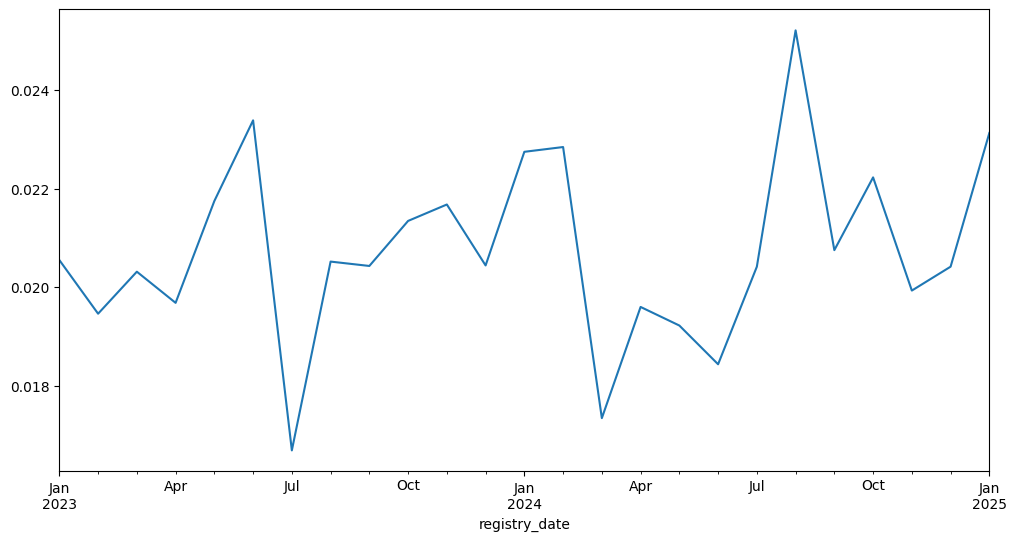

In [28]:
monthly_red = (
    df.groupby(df['registry_date'].dt.to_period('M'))['channel']
    .apply(lambda x: (x == 'VERMELHO').mean())
)

monthly_red.plot(figsize=(12,6))


## Análise de Negócio

In [29]:
# Quais são os 5 NCMs com maior risco de canal vermelho?
ncm_stats = df.groupby('ncm_code')['channel'].agg(
    total='count',
    red_rate=lambda x: (x == 'VERMELHO').mean()
)

ncm_stats.sort_values('red_rate', ascending=False).head(5)
# A taxa média de canal vermelho no dataset é de 2,07%.
# Os NCMs com maior risco de canal vermelho são: 38220090, 22072000, 22071000, 85444200 e 40169990
# Sendo assim, a taxa de vermelho em comparação com a média com o NCM 38220090 é de 2 vezes maior, representando 3,99%, representando risco elevado.

,total,red_rate
ncm_code,,
38220090,3494,0.039496
22072000,3556,0.035996
22071000,3520,0.032670
85444200,3536,0.026301
40169990,3586,0.023982


In [30]:
# Existe sazonalidade na distribuição dos canais? Como isso pode impactar o modelo?
df['month'] = df['registry_date'].dt.month

df.groupby('month')['channel'].apply(lambda x: (x == 'VERMELHO').mean())

# A taxa de canal vermelho por mês apresenta variação limitada, oscilando entre aproximadamente 1,86% e 2,28%, sem padrão sazonal recorrente evidente. 
# As diferenças observadas são pequenas em relação à média global (2,07%), sugerindo ausência de sazonalidade estrutural relevante.

# Sendo assim, o modelo não depende significativamente de efeitos sazonais mensais.

month
1     0.022136
2     0.021200
3     0.018886
4     0.019640
5     0.020481
6     0.020982
7     0.018601
8     0.022838
9     0.020591
10    0.021803
11    0.020821
12    0.020429
Name: channel, dtype: float64

In [31]:
# Qual o impacto do modo de transporte na seleção do canal?
pd.crosstab(df['transport_mode_pt'], df['channel'], normalize='index')

#O modo de transporte apresenta impacto moderado na distribuição dos canais. Observa-se que o transporte ferroviário possui maior proporção de canal verde (98,88%) e menor incidência de vermelho (1,12%), enquanto o transporte aéreo apresenta maior proporção de vermelho (2,44%) e menor de verde (96,59%).

#Além disso, o modal “Entrada/Saída Fictícia” apresenta maior incidência de canal amarelo (2,5%).

#Embora as diferenças não sejam extremas, indicam que o modal está associado a diferentes perfis de risco e pode contribuir para a predição do canal quando combinado com outras variáveis.

channel,AMARELO,CINZA,VERDE,VERMELHO
transport_mode_pt,,,,
AEREA,0.009107,0.000529,0.965941,0.024423
ENTRADA/SAÍDA FICTÍCIA,0.025641,0.000000,0.974359,0.000000
FERROVIARIA,0.000000,0.000000,0.988764,0.011236
MARITIMA,0.008173,0.000421,0.973529,0.017877
MEIOS PRÓPRIOS,0.000000,0.000000,0.978261,0.021739
POSTAL,0.008636,0.000000,0.970639,0.020725
RODOVIARIA,0.010555,0.000459,0.973382,0.015603
UNKNOWN,0.000000,0.000000,1.000000,0.000000


In [32]:
# Como o porte da empresa importadora influencia o canal selecionado?

pd.crosstab(df['consignee_company_size'], df['channel'], normalize='index')

#A análise da distribuição dos canais por porte da empresa revela padrão consistente de maior fiscalização para empresas de menor porte. Microempresas apresentam taxa de canal vermelho de 2,82%, enquanto empresas de pequeno porte apresentam 2,76%, ambas superiores à média geral de 2,07%.

#Além disso, microempresas também apresentam maior incidência de canal amarelo e são as únicas com ocorrência relevante de canal cinza.

#Esses resultados sugerem que o porte da empresa está associado ao perfil de risco fiscal, possivelmente refletindo diferenças na estrutura de compliance e histórico operacional. Portanto, essa variável demonstra potencial relevância para a modelagem preditiva.


channel,AMARELO,CINZA,VERDE,VERMELHO
consignee_company_size,,,,
DEMAIS,0.008500,0.000476,0.970614,0.020409
EMPRESA DE PEQUENO PORTE,0.011376,0.000000,0.961111,0.027513
MICRO EMPRESA,0.013274,0.002212,0.957965,0.026549


# Modelagem
Conjunto de dados:

Treino: 2023-01-01 → 2024-09-30

Validação: 2024-10-01 → 2024-12-31

Teste: 2025-01-01 → 2025-01-31 (ou até 2025-01-31)

In [58]:
# Garantir que registry_date é datetime
df['registry_date'] = pd.to_datetime(df['registry_date'])

train = df[(df['registry_date'] >= '2023-01-01') & 
           (df['registry_date'] <= '2024-09-30')]

val = df[(df['registry_date'] >= '2024-10-01') & 
         (df['registry_date'] <= '2024-12-31')]

test = df[(df['registry_date'] >= '2025-01-01') & 
          (df['registry_date'] <= '2025-01-31')]

In [59]:
target = 'channel'

X_train = train.drop(columns=[target, 'document_number'])
y_train = train[target]

X_val = val.drop(columns=[target, 'document_number'])
y_val = val[target]

X_test = test.drop(columns=[target, 'document_number'])
y_test = test[target]

In [60]:
numeric_features = [ 'year', 'month', 'weekday']

categorical_features = [
    'clearance_place_dispatch',
    'clearance_place_entry',
    'consignee_company_size',
    'clearance_place',
    'transport_mode_pt',
    'ncm_code',
    'country_origin_code'
]

In [61]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, balanced_accuracy_score 

model_rus = ImbPipeline(steps=[
    ('preprocessor', preprocessor),  # pode ser sparse aqui (melhor pra memória)
    ('under', rus),
    ('clf', LogisticRegression(class_weight='balanced'))
])

model_rus.fit(X_train, y_train)

C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the numb

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'month', 'weekday']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['clearance_place_dispatch',
                                                   'clearance_place_entry',
                                                   'consignee_company_size',
                                                   'clearance_place',
                                                   'transport_mode_pt',
                                                   'ncm_code',
                                                   'country_origin_code'])])),
                ('under',
                 RandomUnderSampler(random_state=42,
                                    sampling_strategy={'AMARELO': 725,
                                                       'CINZA': 38,
                                                       'VERDE': 8570,
                                                       'VERMELHO': 1714})),
                ('clf', LogisticRegression(class_weight='balanced'))])

In [64]:

y_pred_val = model_rus.predict(X_val) 
print(classification_report(y_val, y_pred_val)) 
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred_val))

              precision    recall  f1-score   support

     AMARELO       0.01      0.25      0.01        95
       CINZA       0.00      0.00      0.00         8
       VERDE       0.98      0.29      0.44     12580
    VERMELHO       0.03      0.39      0.05       272

    accuracy                           0.29     12955
   macro avg       0.25      0.23      0.13     12955
weighted avg       0.95      0.29      0.43     12955

Balanced Accuracy: 0.23210662287674672


In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, balanced_accuracy_score

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

y_pred_val_rf = model_rf.predict(X_val)


print(classification_report(y_val, y_pred_val_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred_val_rf))

C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\55329\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

              precision    recall  f1-score   support

     AMARELO       0.00      0.00      0.00        95
       CINZA       0.00      0.00      0.00         8
       VERDE       0.97      1.00      0.99     12580
    VERMELHO       0.00      0.00      0.00       272

    accuracy                           0.97     12955
   macro avg       0.24      0.25      0.25     12955
weighted avg       0.94      0.97      0.96     12955

Balanced Accuracy: 0.25


In [ ]:
git